<a href="https://colab.research.google.com/github/monishms2128/3DAYSHACKATHONCUMWORKSHOPPRACTICES/blob/main/DAY2CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
class_names=["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [ ]:
y_train=keras.utils.to_categorical(y_train,10)
y_test=keras.utils.to_categorical(y_test,10)

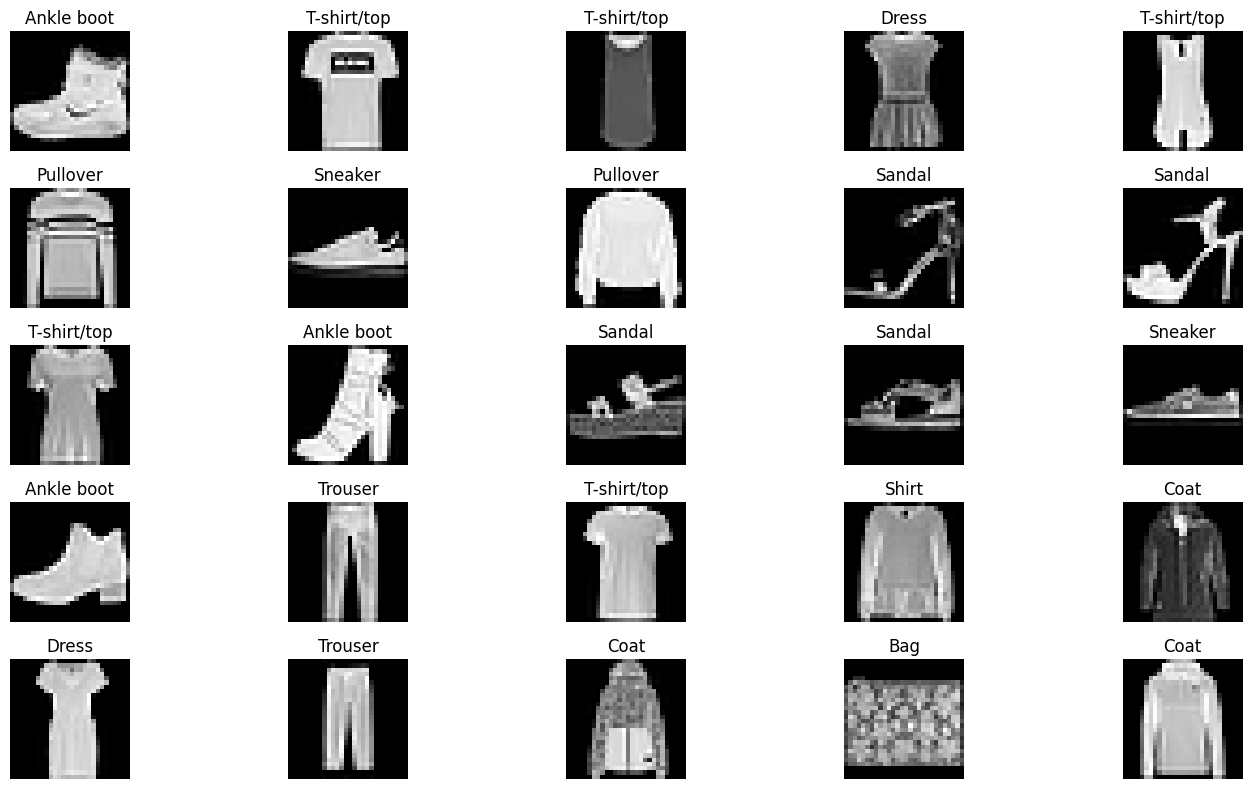

In [ ]:
plt.figure(figsize=(15,8))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i].reshape(28,28),cmap="gray")
  plt.title(class_names[np.argmax(y_train[i])])
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
model=keras.Sequential([
    layers.Conv2D(64,(3,3),activation="relu",input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32,(3,3),activation="relu"),
    layers.Flatten(),
    layers.Dense(32,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10,activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,930 (148.16 KB)

 Trainable params: 37,930 (148.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
data_augmentation=keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
augmented_train_data=data_augmentation(x_train)

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(augmented_train_data,y_train,epochs=20,batch_size=64,validation_data=(x_test,y_test),verbose=1)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.6257 - loss: 1.0167 - val_accuracy: 0.7619 - val_loss: 0.6088
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.7400 - loss: 0.7058 - val_accuracy: 0.7845 - val_loss: 0.5949
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.7714 - loss: 0.6276 - val_accuracy: 0.7923 - val_loss: 0.5867
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.7888 - loss: 0.5750 - val_accuracy: 0.8094 - val_loss: 0.5265
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.8057 - loss: 0.5330 - val_accuracy: 0.8305 - val_loss: 0.4660
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.8182 - loss: 0.5033 - val_accuracy: 0.8289 - val_loss: 0.4782
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.8267 - loss: 0.4772 - val_accuracy: 0.8455 - val_loss: 0.4406
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.8349 - loss: 0.4564 - 

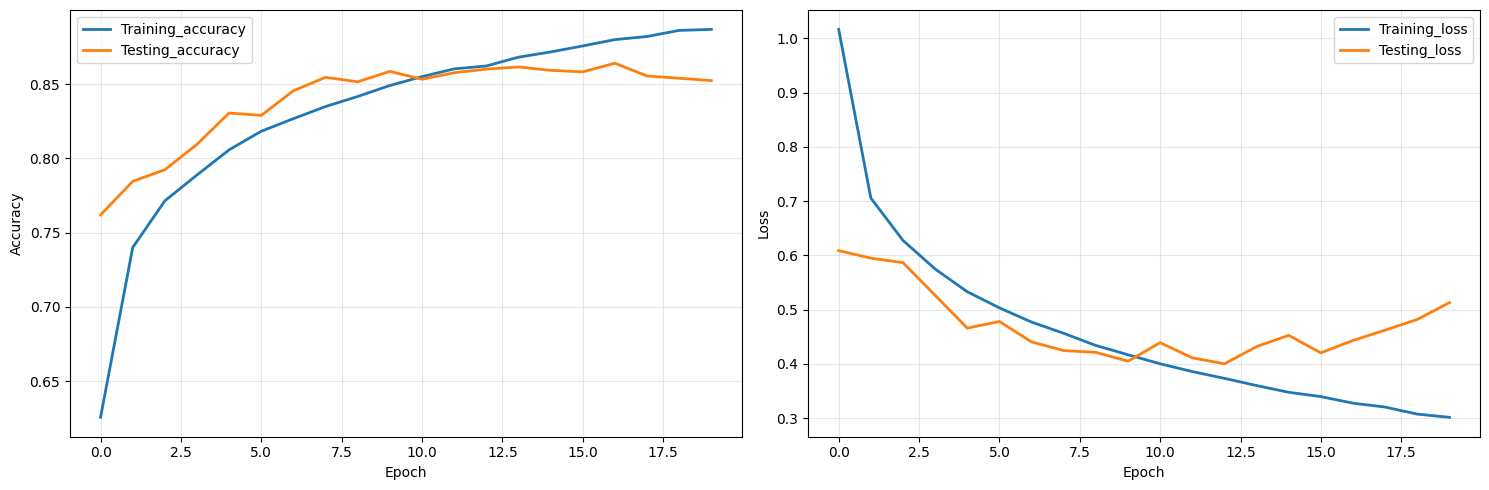

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],label="Training_accuracy",linewidth=2)
plt.plot(history.history["val_accuracy"],label="Testing_accuracy",linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True,alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="Training_loss",linewidth=2)
plt.plot(history.history["val_loss"],label="Testing_loss",linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

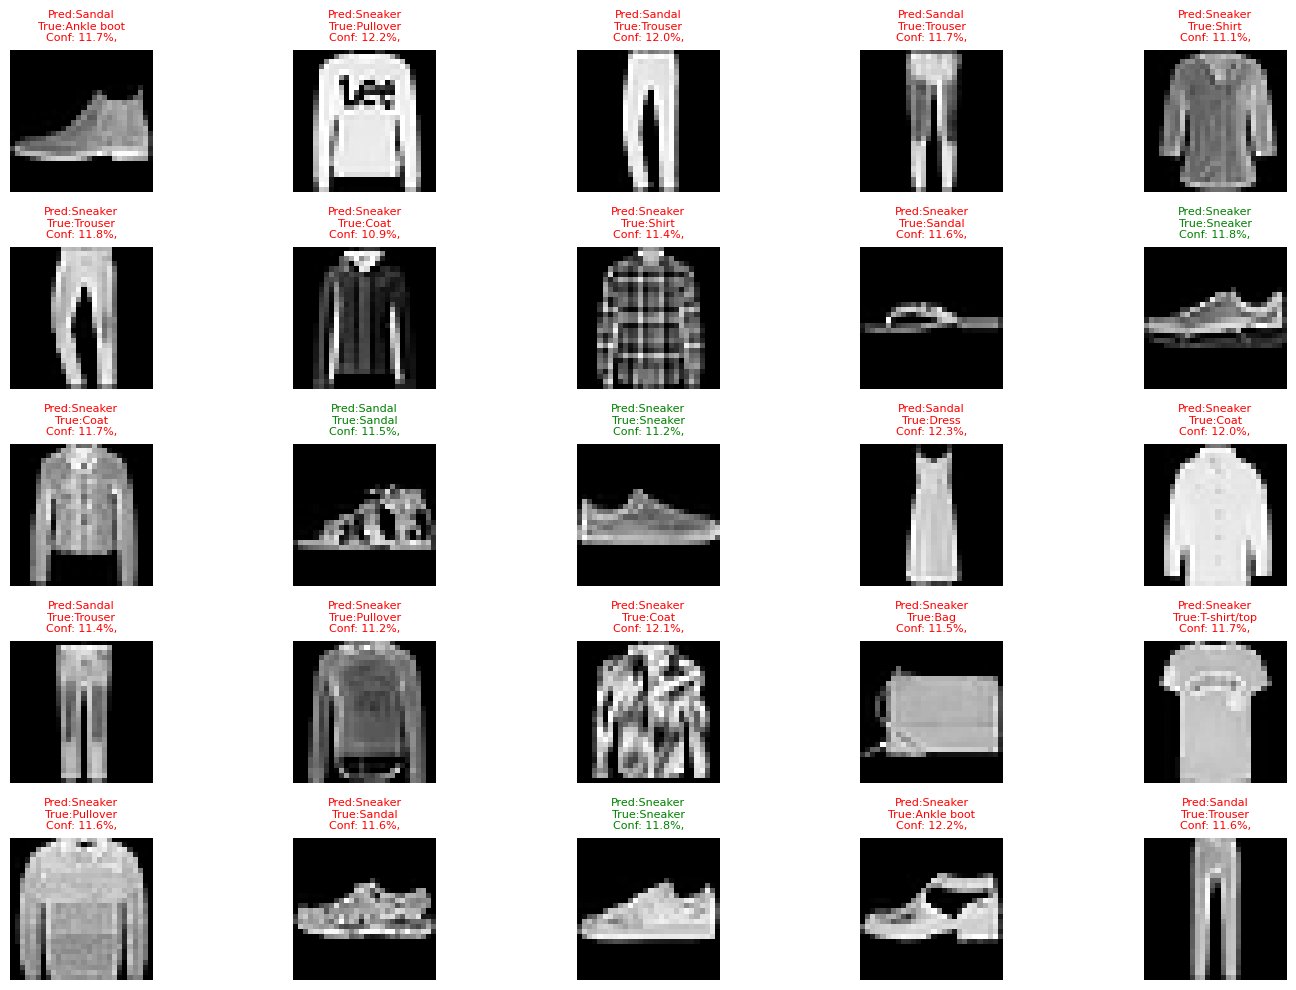

In [ ]:
predictions=model.predict(x_test[:25],verbose=0)
predicted_labels=np.argmax(predictions,axis=1)
true_labels=np.argmax(y_test[:25],axis=1)

plt.figure(figsize=(15,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap="gray")
  true_label=class_names[true_labels[i]]
  pred_label=class_names[predicted_labels[i]]
  confidence=np.max(predictions[i])*100
  color="green" if pred_label==true_label else "red"
  plt.title(f"Pred:{pred_label}\nTrue:{true_label}\nConf: {confidence:.1f}%,",color=color,fontsize=8)
  plt.axis("off")
plt.tight_layout()
plt.show()